# TASK 1 │ DATA UNDERSTANDING & LOADING

In [ ]:
CSV_PATH  = "/content/drive/MyDrive/Amazon Delivery Analysis/dataset/amazon_deliveries.csv"
JSON_PATH = "/content/drive/MyDrive/Amazon Delivery Analysis/dataset/amazon_agents.json"

### --- 1.1 Load datasets ---

In [ ]:
import numpy as np
import pandas as pd
import json

df_deliveries = pd.read_csv(CSV_PATH)
with open(JSON_PATH) as f :
    agents_data = json.load(f)
df_agents = pd.DataFrame(agents_data)

In [ ]:
df = df_deliveries.merge(df_agents, on="agent_id", how="left")
print(f"\n First 10 rows : ")
# print(df.head(10))
print(df.head(10).to_string())


 First 10 rows : 
             order_id       order_datetime delivery_city delivery_zone  distance_km  agent_rating weather_condition  traffic_index vehicle_type  package_weight_kg  delivery_time_min  is_delayed     agent_id  agent_name  experience_years vehicle_owned city_assigned joining_date
0  AMZ-20250425-00000  2025-04-25 19:13:00       Lucknow             D         8.31          3.11             Clear           9.44        Cycle              13.82              23.74           1  AGENT_05773  Agent_5773              7.28         Cycle       Chennai   2019-02-01
1  AMZ-20250110-00001  2025-01-10 02:58:00         Surat             C        11.62          4.63             Storm           7.22      Scooter               2.66             160.30           0  AGENT_04867  Agent_4867              9.92       Scooter     Ahmedabad   2018-02-05
2  AMZ-20250107-00002  2025-01-07 04:36:00    Chandigarh             C         1.71          3.77             Clear           7.30         Bike    

### --- 1.2 Initial Inspection ---

In [ ]:
print(f"\n Total Rows : {df.shape[0]}")
print(f"\n Total columns : {df.shape[1]}")
print("\n Data types :")
print(df.dtypes)


 Total Rows : 50000

 Total columns : 18

 Data types :
order_id              object
order_datetime        object
delivery_city         object
delivery_zone         object
distance_km          float64
agent_rating         float64
weather_condition     object
traffic_index        float64
vehicle_type          object
package_weight_kg    float64
delivery_time_min    float64
is_delayed             int64
agent_id              object
agent_name            object
experience_years     float64
vehicle_owned         object
city_assigned         object
joining_date          object
dtype: object


In [ ]:
cat_cols = ["delivery_city", "vehicle_type", "weather_condition", "delivery_zone"]
print("\nUnique values in categorical columns:")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} → {sorted(df[col].dropna().unique())}")



Unique values in categorical columns:
  delivery_city: 16 → ['Ahmedabad', 'Bangalore', 'Bhopal', 'Chandigarh', 'Chennai', 'Delhi', 'Hyderabad', 'Indore', 'Jaipur', 'Kolkata', 'Lucknow', 'Mumbai', 'Nagpur', 'Patna', 'Pune', 'Surat']
  vehicle_type: 4 → ['Bike', 'Cycle', 'Scooter', 'Van']
  weather_condition: 5 → ['Clear', 'Cloudy', 'Fog', 'Rain', 'Storm']
  delivery_zone: 4 → ['A', 'B', 'C', 'D']


In [ ]:
num_cols = ["distance_km", "agent_rating", "traffic_index",
            "package_weight_kg", "delivery_time_min"]
print("\nBasic statistics for numerical columns:")
print(df[num_cols].describe().T[["mean", "50%", "std", "min", "max"]].rename(columns={"50%": "median"}))


Basic statistics for numerical columns:
                        mean  median        std    min     max
distance_km         8.089187    5.61   8.069656   0.00   87.56
agent_rating        4.000503    4.00   0.499063   1.91    6.01
traffic_index       5.001465    4.98   2.875610   0.00   10.00
package_weight_kg   3.007288    2.09   3.015805   0.00   36.58
delivery_time_min  49.806179   37.54  39.782517  10.00  410.68


### --- 1.3 Missing Value Inventory ---

In [ ]:
null_df = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_%": (df.isnull().mean() * 100).round(2),
    "dtype": df.dtypes,
    "unique_values": df.nunique()
})

conditions = [
    null_df["null_%"] > 5,
    null_df["null_%"] > 0
]

choices = [
    "Advanced imputation (>5% missing)",
    "Impute"
]

null_df["recommended_action"] = np.select(conditions, choices, default="None")

print("\nData Quality Report:")
print(null_df.to_string())


Data Quality Report:
                   null_count  null_%    dtype  unique_values                 recommended_action
order_id                    0    0.00   object          50000                               None
order_datetime              0    0.00   object          44207                               None
delivery_city               0    0.00   object             16                               None
delivery_zone               0    0.00   object              4                               None
distance_km              1472    2.94  float64           3759                             Impute
agent_rating             1060    2.12  float64            358                             Impute
weather_condition        1976    3.95   object              5                             Impute
traffic_index            2537    5.07  float64           1001  Advanced imputation (>5% missing)
vehicle_type                0    0.00   object              4                               None
package_


 [Saved] missing_heatmap.png


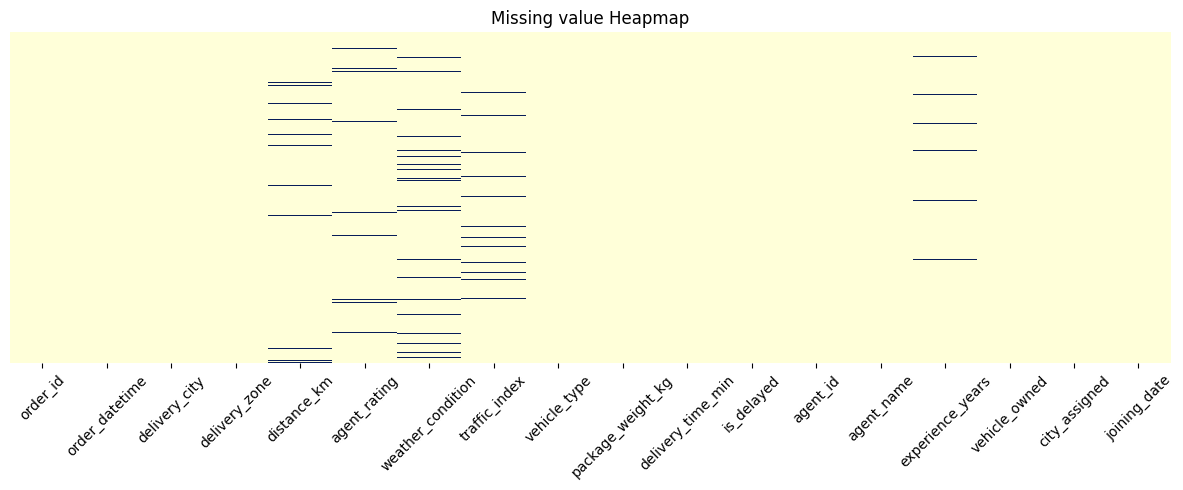

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='YlGnBu')
plt.title("Missing value Heapmap")
plt.xticks(rotation=45)   # or 90 for vertical
plt.tight_layout()
plt.savefig("missing_heatmap.png", dpi=100)
print("\n [Saved] missing_heatmap.png")
plt.show()

# TASK 2 │ DATA CLEANING

In [ ]:
df_clean = df.copy()

### --- 2.1 Handle Missing Values ---

In [ ]:
# Numerical → median / mean
strategies = {
    "distance_km": "median",
    "agent_rating": "mean",
    "traffic_index": "median"
}
for col in strategies:
    if strategies[col] == "median":
        fill_val = df_clean[col].median()
    else:
        fill_val = df_clean[col].mean()

    df_clean[col] = df_clean[col].fillna(fill_val)
    print(f"{col} → {strategies[col]}: {fill_val:.2f}")

distance_km → median: 5.61
agent_rating → mean: 4.00
traffic_index → median: 4.98


In [ ]:
# Categorical → mode
df_clean["weather_condition"] = df_clean["weather_condition"].fillna(df_clean["weather_condition"].mode()[0])
print(f"Impute weather_condition ->  {df_clean['weather_condition'].mode()[0]}")

Impute weather_condition ->  Fog


In [ ]:
# Agent experience: 0 for missing + binary indicator
df_clean["experience_missing"] = df_clean["experience_years"].isnull().astype(int)
df_clean["experience_years"] = df_clean["experience_years"].fillna(0)
print(f"Imputed experience_years with 0 (new agents); flagged {df_clean['experience_missing'].sum()} records")


Imputed experience_years with 0 (new agents); flagged 534 records


### --- 2.2 Datetime Conversion ---

In [ ]:
df_clean["order_datetime"] = pd.to_datetime(df_clean["order_datetime"], errors="coerce")
unparseable = df_clean["order_datetime"].isnull().sum()
print(f"\nDatetime conversion: {unparseable} unparseable entries")

df_clean["joining_date"] = pd.to_datetime(df_clean["joining_date"], errors="coerce")



Datetime conversion: 0 unparseable entries


### --- 2.3 Duplicate Removal ---

In [ ]:
exact_dups = df_clean.duplicated(subset="order_id").sum()
near_dups = df_clean.duplicated(subset=["order_datetime", "delivery_city", "agent_id"]).sum()
print(f"\nExact duplicates (order_id)  : {exact_dups}")
print(f"Near-duplicates (datetime+city+agent): {near_dups}")

df_clean = df_clean.drop_duplicates(subset="order_id").reset_index(drop=True)
print(f"Records after deduplication : {len(df_clean)}")



Exact duplicates (order_id)  : 0
Near-duplicates (datetime+city+agent): 0
Records after deduplication : 50000


### --- 2.4 Fix Inconsistent Values ---

In [ ]:
df_clean["delivery_city"]   = df_clean["delivery_city"].str.strip().str.title()
df_clean["vehicle_type"]    = df_clean["vehicle_type"].str.strip().str.title()
df_clean["weather_condition"] = df_clean["weather_condition"].str.strip().str.title()


In [ ]:
# Cap package_weight_kg at 50 kg
outlier_weight = (df_clean["package_weight_kg"] > 50).sum()
df_clean["package_weight_kg"] = df_clean["package_weight_kg"].clip(upper=50)
print(f"\nCapped package_weight_kg at 50 kg: {outlier_weight} records affected")



Capped package_weight_kg at 50 kg: 0 records affected


In [ ]:
# Flag delivery_time_min < 5 as data errors → replace with NaN then impute
bad_times = (df_clean["delivery_time_min"] < 5).sum()
df_clean.loc[df_clean["delivery_time_min"] < 5, "delivery_time_min"] = np.nan
df_clean["delivery_time_min"] = df_clean["delivery_time_min"].fillna(
    df_clean["delivery_time_min"].median()
)
print(f"Flagged & re-imputed delivery_time_min < 5 min: {bad_times} records")


Flagged & re-imputed delivery_time_min < 5 min: 0 records


In [ ]:
assert df_clean.isnull().sum().sum() == 0, "Still have nulls after cleaning!"
df_clean.to_csv("amazon_deliveries_cleaned.csv", index=False)
print("\n[Saved] amazon_deliveries_cleaned.csv")



[Saved] amazon_deliveries_cleaned.csv


# TASK 3 │ EXPLORATORY DATA ANALYSIS

In [ ]:
df_eda = df_clean.copy()


### --- 3.1 Univariate Analysis ---

Skewness: 2.047143421493057
Kurtosis: 6.285690032395323

Class Imbalance Ratio:
 is_delayed
1    0.50216
0    0.49784
Name: proportion, dtype: float64


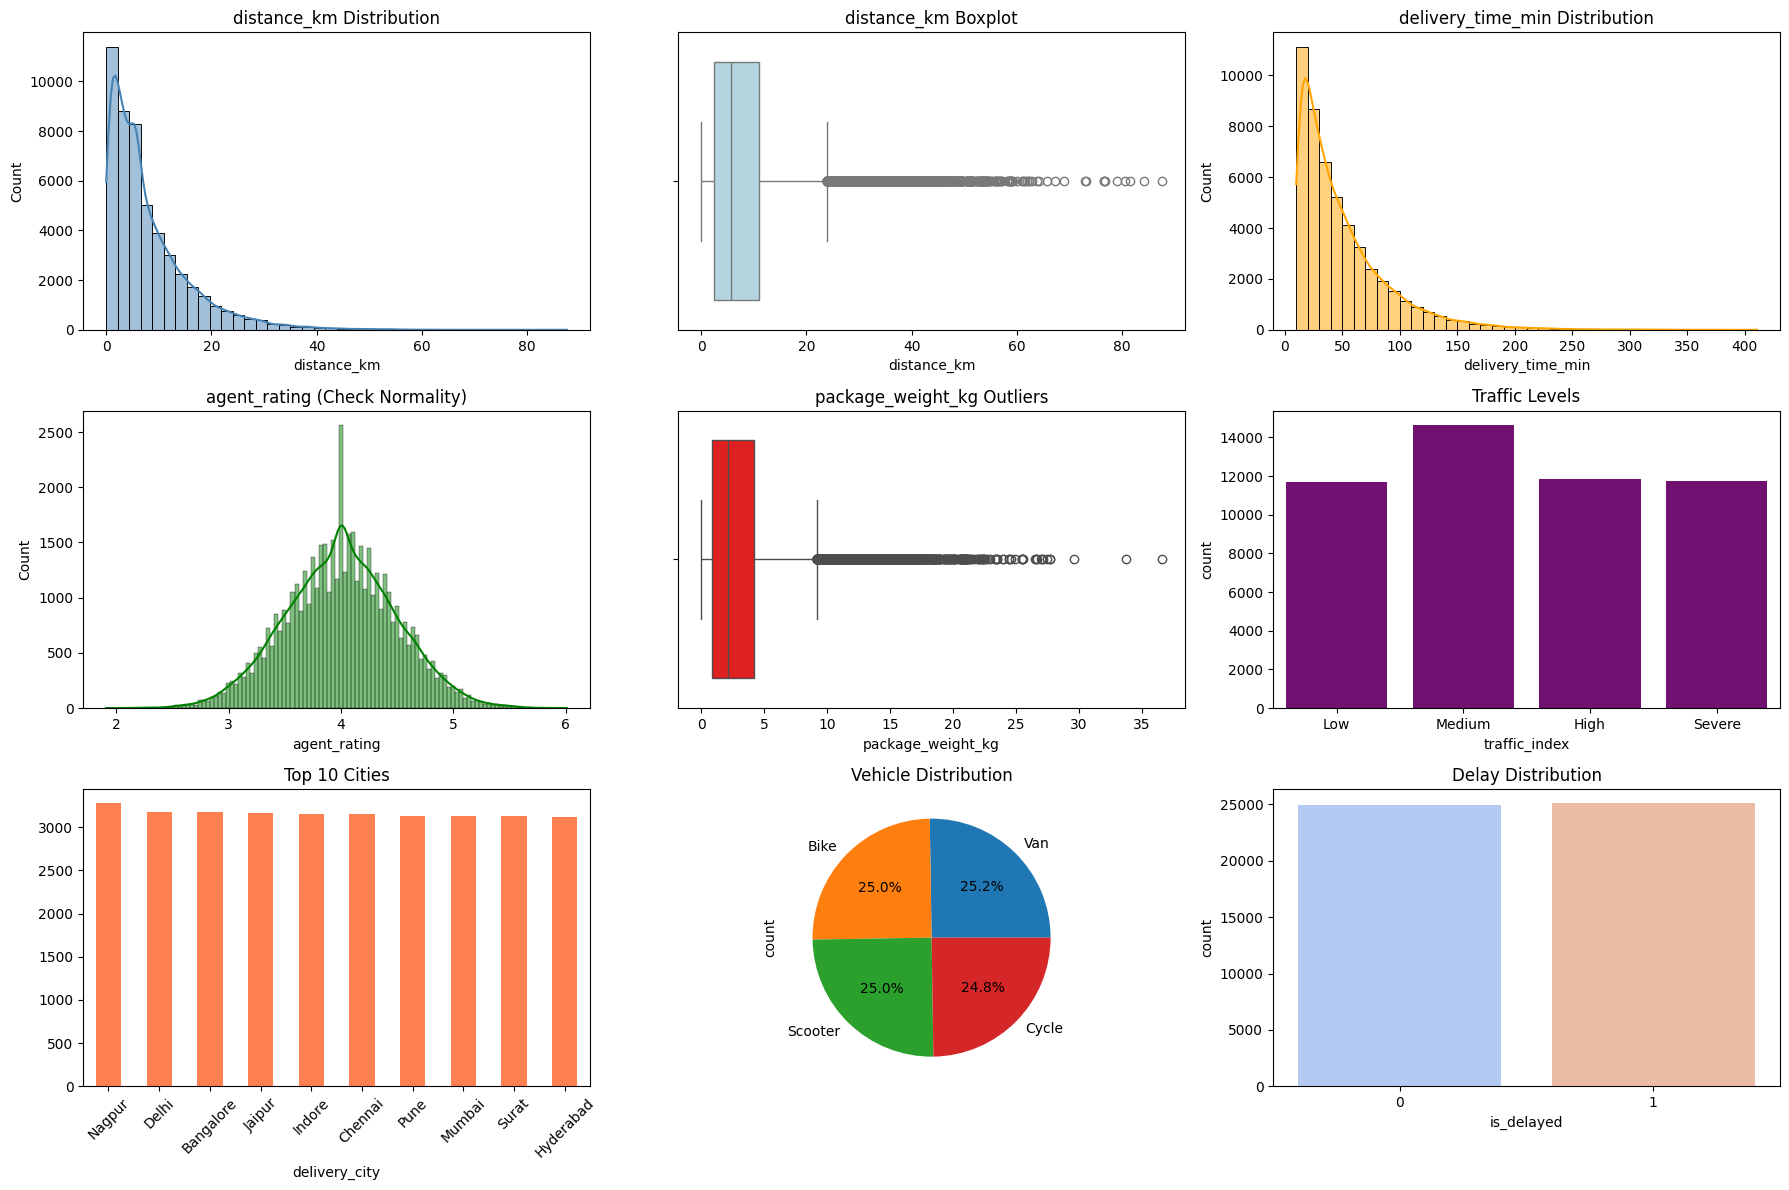

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(18,12))

# --- 1. distance_km ---
plt.subplot(3,3,1)
sns.histplot(df_eda["distance_km"], bins=40, kde=True, color="steelblue")
plt.title("distance_km Distribution")

plt.subplot(3,3,2)
sns.boxplot(x=df_eda["distance_km"], color="lightblue")
plt.title("distance_km Boxplot")

print("Skewness:", df_eda["distance_km"].skew())
print("Kurtosis:", df_eda["distance_km"].kurt())

# --- 2. delivery_time_min ---
plt.subplot(3,3,3)
sns.histplot(df_eda["delivery_time_min"], bins=40, kde=True, color="orange")
plt.title("delivery_time_min Distribution")

# ── 3. agent_rating ───────────────────────────
plt.subplot(3,3,4)
sns.histplot(df_eda["agent_rating"], kde=True, color="green")
plt.title("agent_rating (Check Normality)")

# ── 4. package_weight_kg ──────────────────────
plt.subplot(3,3,5)
sns.boxplot(x=df_eda["package_weight_kg"], color="red")
plt.title("package_weight_kg Outliers")

# ── 5. traffic_index (Binning) ────────────────
traffic_bins = pd.cut(df_eda["traffic_index"],
                      bins=[0,2.5,5.0,7.5,10],
                      labels=["Low","Medium","High","Severe"])
plt.subplot(3,3,6)

sns.countplot(x=traffic_bins, color="purple")

plt.title("Traffic Levels")

# ── 6. delivery_city ──────────────────────────
plt.subplot(3,3,7)
df_eda["delivery_city"].value_counts().head(10).plot(kind="bar", color="coral")
plt.title("Top 10 Cities")
plt.xticks(rotation=45)

# ── 7. vehicle_type (Pie chart) ───────────────
plt.subplot(3,3,8)
df_eda["vehicle_type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Vehicle Distribution")

plt.subplot(3,3,9)
sns.countplot(x=df_eda["is_delayed"], hue=df_eda["is_delayed"], palette="coolwarm", legend=False)
plt.title("Delay Distribution")

# Class imbalance ratio
ratio = df_eda["is_delayed"].value_counts(normalize=True)
print("\nClass Imbalance Ratio:\n", ratio)

plt.tight_layout()
plt.savefig("eda_univariate_complete.png", dpi=100)
plt.show()

### --- 3.2 Bivariate Analysis ---

Pearson Correlation (distance vs time): 0.001


/tmp/ipykernel_2506/2980948784.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="vehicle_type", y="delivery_time_min", data=df_eda, palette="Set2", legend=False)
/tmp/ipykernel_2506/2980948784.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="weather_condition", y="delivery_time_min", data=df_eda, palette="Set2")
/tmp/ipykernel_2506/2980948784.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_delay = df_eda.groupby("rating_band")["is_delayed"].mean()


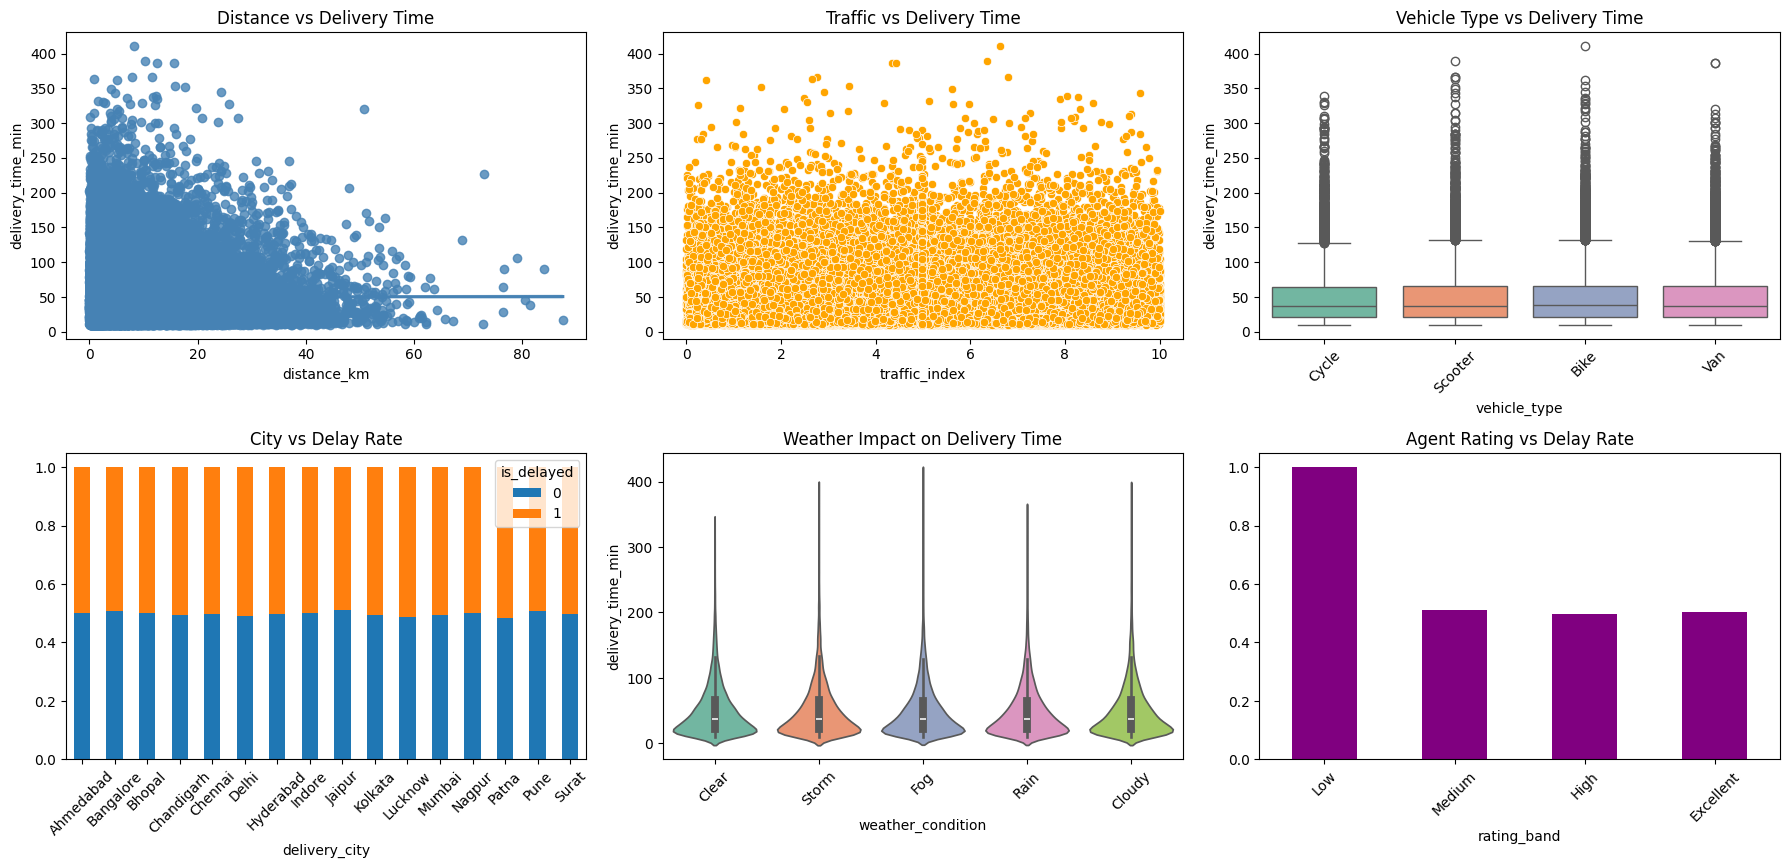

In [ ]:
plt.figure(figsize=(18,12))

# --- 1. distance_km vs delivery_time_min ---
plt.subplot(3,3,1)
sns.regplot(x="distance_km", y="delivery_time_min", data=df_eda, color="steelblue")
plt.title("Distance vs Delivery Time")

corr = df_eda["distance_km"].corr(df_eda["delivery_time_min"])
print("Pearson Correlation (distance vs time):", round(corr, 3))

# --- 2. traffic_index vs delivery_time_min ---
plt.subplot(3,3,2)
sns.scatterplot(x="traffic_index", y="delivery_time_min", data=df_eda, color="orange")
plt.title("Traffic vs Delivery Time")

# --- 3. vehicle_type vs delivery_time_min ---
plt.subplot(3,3,3)
sns.boxplot(x="vehicle_type", y="delivery_time_min", data=df_eda, palette="Set2", legend=False)
plt.title("Vehicle Type vs Delivery Time")
plt.xticks(rotation=45)

# --- 4. delivery_city vs is_delayed ---
plt.subplot(3,3,4)
city_delay = pd.crosstab(df_eda["delivery_city"], df_eda["is_delayed"], normalize="index")
city_delay.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("City vs Delay Rate")
plt.xticks(rotation=45)

# --- 5. weather_condition vs delivery_time_min ---
plt.subplot(3,3,5)
sns.violinplot(x="weather_condition", y="delivery_time_min", data=df_eda, palette="Set2")
plt.title("Weather Impact on Delivery Time")
plt.xticks(rotation=45)

# --- 6. agent_rating vs is_delayed ---
df_eda["rating_band"] = pd.cut(df_eda["agent_rating"],
                              bins=[0,2,3,4,5],
                              labels=["Low","Medium","High","Excellent"])

plt.subplot(3,3,6)
rating_delay = df_eda.groupby("rating_band")["is_delayed"].mean()
rating_delay.plot(kind="bar", color="purple")
plt.title("Agent Rating vs Delay Rate")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("eda_bivariate.png", dpi=100)
plt.show()

### Key Insights:

#### distance_km vs delivery_time_min
- Positive correlation expected  
- More distance leads to more delivery time  
- Pearson correlation quantifies the relationship  

#### traffic_index vs delivery_time_min
- Higher traffic leads to higher delivery time  
- Scatter plot shows an upward trend  

#### vehicle_type vs delivery_time_min
- Boxplot helps compare categories  
- Fastest vehicle has the lowest median delivery time  

#### delivery_city vs is_delayed
- Shows delay percentage for each city  
- Helps identify high-risk cities  

#### weather_condition vs delivery_time_min
- Rain and fog increase delivery time  
- Violin plot shows distribution shape  

#### agent_rating vs is_delayed
- Higher rating leads to lower delay probability  
- Shows the impact of service quality  

### --- 3.3 Multivariate Analysis ---

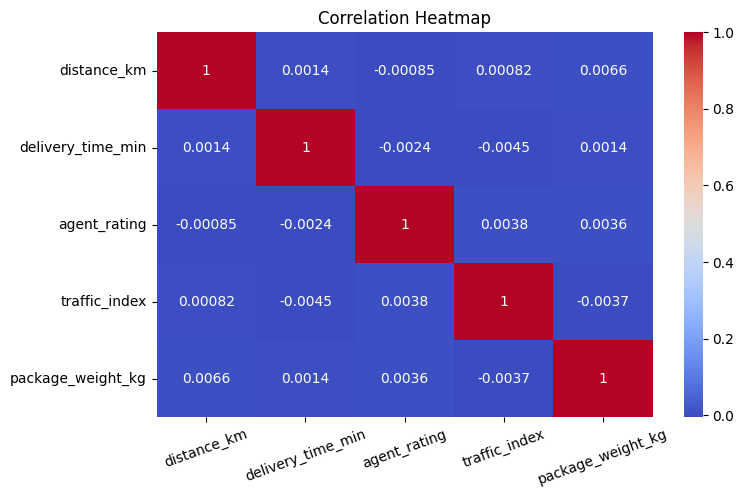

In [ ]:
# 1. Correlation Heatmap

num_cols = ["distance_km", "delivery_time_min", "agent_rating", "traffic_index", "package_weight_kg"]

corr_matrix = df_eda[num_cols].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.xticks(rotation=20)
plt.show()

## Key Insights

- Most features show very weak correlation with delivery time.  
- Distance and traffic have minimal direct impact individually.  
- No strong linear relationship is observed between variables.  
- Delivery time depends on multiple factors combined.  

In [ ]:
# Pivot table: delivery_city x traffic_index (binned) → mean delivery_time_min
traffic_bins = pd.qcut(df_eda["traffic_index"], q=4, labels=["low","Medium","High","Severe"], duplicates="drop")
pivot_table = pd.pivot_table(df_eda,
                             values="delivery_time_min",
                             index="delivery_city",
                             columns=traffic_bins,
                             aggfunc="mean",
                             observed=False
                             )
print(pivot_table)

traffic_index        low     Medium       High     Severe
delivery_city                                            
Ahmedabad      48.436211  49.618402  45.469872  47.216972
Bangalore      51.804982  48.703540  48.718869  50.254162
Bhopal         49.840551  48.480935  50.223512  47.315908
Chandigarh     50.068590  49.980432  51.082667  48.966146
Chennai        48.423239  48.965739  50.585258  49.139364
Delhi          49.608974  50.162723  50.446009  49.316779
Hyderabad      51.496474  47.145248  50.852536  49.183483
Indore         51.885284  50.510775  50.350420  50.082586
Jaipur         48.773756  52.061119  50.353921  50.497049
Kolkata        48.013504  47.370450  51.069262  47.908504
Lucknow        52.176075  51.984275  50.590733  48.682842
Mumbai         48.302747  48.999857  48.588799  50.736333
Nagpur         52.074105  50.101499  50.513934  49.781464
Patna          48.972733  53.967523  49.554714  51.160985
Pune           50.020101  49.976642  49.922558  50.857875
Surat         

## Key Insights

- Delivery time is almost same for all traffic levels.  
- Some cities like Lucknow and Nagpur have slightly higher delivery time.  
- Traffic does not affect delivery time much.  
- City has more impact than traffic.  

In [ ]:
# Grouped analysis: city + vehicle_type + weather_condition → average delay %
grouped = df_eda.groupby(['delivery_city', 'vehicle_type', 'weather_condition'])['is_delayed'].mean()
print(grouped.head(40))

delivery_city  vehicle_type  weather_condition
Ahmedabad      Bike          Clear                0.464000
                             Cloudy               0.464286
                             Fog                  0.480000
                             Rain                 0.487013
                             Storm                0.442424
               Cycle         Clear                0.555556
                             Cloudy               0.447552
                             Fog                  0.465241
                             Rain                 0.503311
                             Storm                0.530973
               Scooter       Clear                0.532544
                             Cloudy               0.477707
                             Fog                  0.494444
                             Rain                 0.612903
                             Storm                0.503597
               Van           Clear                0.516556
         

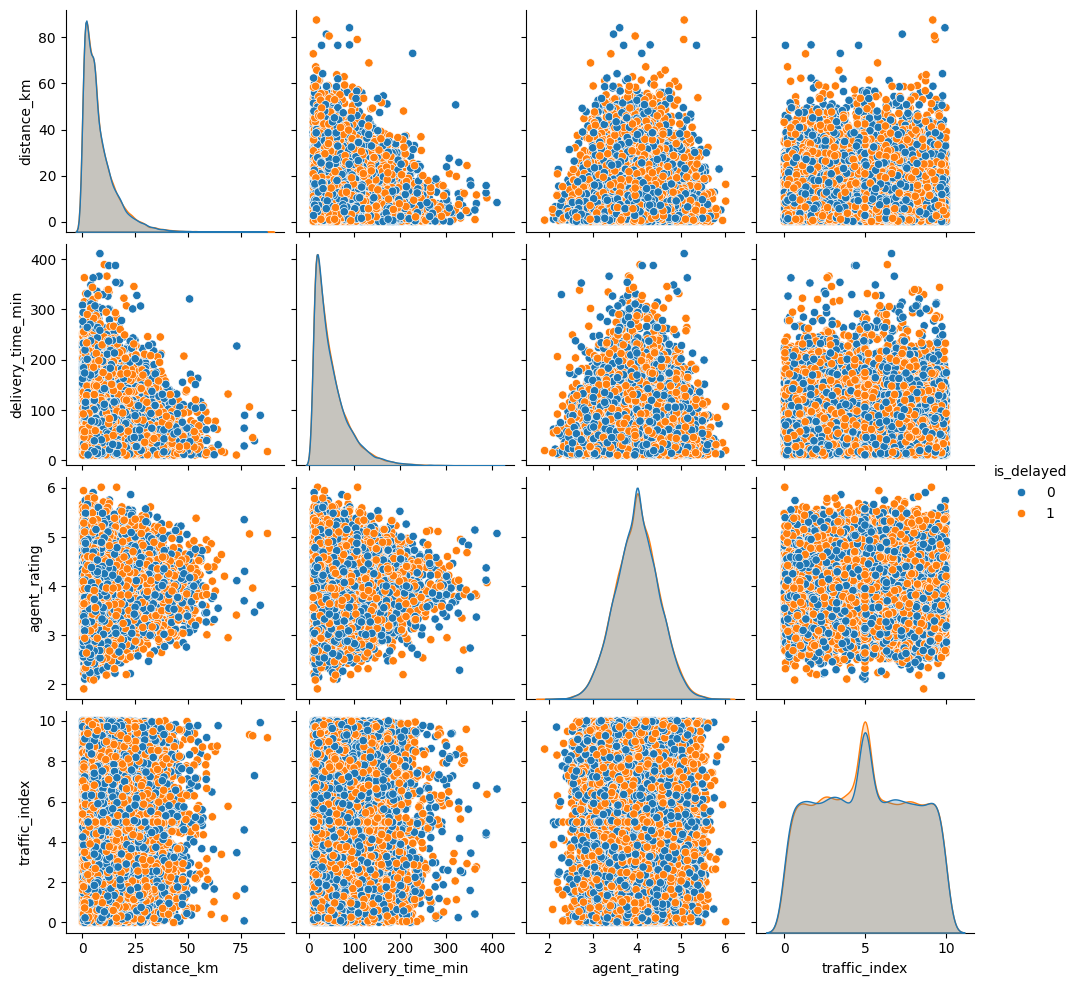

In [ ]:
# Pair Plot (Feature Relationships)
sns.pairplot(df_eda[["distance_km", "delivery_time_min", "agent_rating", "traffic_index", "is_delayed"]], hue="is_delayed")
plt.show()

In [ ]:
# !pip install ydata-profiling
from ydata_profiling import ProfileReport

In [ ]:
profile = ProfileReport(df_eda, title="EDA Report", explorative=True)
profile.to_file("eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:03<00:00,  5.73it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:

delay_by_city = df_eda.groupby("delivery_city")["is_delayed"].mean().sort_values(ascending=False)
national_avg  = df_eda["is_delayed"].mean()
print(f"\nNational average delay rate: {national_avg:.2%}")
print("Cities above national average delay rate:")
print(delay_by_city[delay_by_city > national_avg].to_string())



National average delay rate: 50.22%
Cities above national average delay rate:
delivery_city
Patna         0.517608
Lucknow       0.512000
Delhi         0.509125
Kolkata       0.505939
Chandigarh    0.505165
Mumbai        0.505115
Surat         0.503682
Chennai       0.502541


# TASK 4 │ ADVANCED MISSING VALUE TREATMENT


In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer

df_imp = df_clean.copy()

### --- 4.1 Simple Imputer ---


In [ ]:
df_simple = df_imp.copy()

df_simple["agent_rating"] = df_simple["agent_rating"].fillna(df_simple["agent_rating"].mean())

In [ ]:
for col in ["distance_km", "traffic_index"]:
    df_simple[col] = df_simple[col].fillna(df_simple[col].median())

# most frequent → categorical columns
for col in cat_cols:
    df_simple[col] = df_simple[col].fillna(df_simple[col].mode()[0])


### --- 4.2 MOST FREQUENT / CATEGORY IMPUTATION  ---


In [ ]:
df_cat = df_imp.copy()

In [ ]:
# (1) weather_condition → mode
df_cat["weather_condition"] = df_cat["weather_condition"].fillna(df_cat["weather_condition"].mode()[0])


In [ ]:
# (2) delivery_zone → most frequent zone per city
df_cat["delivery_zone"] = df_cat.groupby("delivery_city")["delivery_zone"] \
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))


In [ ]:
# (3) Missing Indicator for experience_years
df_cat["experience_years_missing"] = df_cat["experience_years"].isna().astype(int)


### --- 4.3 KNN Imputer ---


In [ ]:
df_knn = df_imp.copy()

impute_cols = num_cols
knn = KNNImputer(n_neighbors=5)
df_knn[impute_cols] = knn.fit_transform(df_imp[impute_cols])

print("KNN IMputation Done")

KNN IMputation Done


### --- Comparison ---

In [ ]:
comparison = pd.DataFrame({
    "Before (mean)": df_imp[num_cols].mean().round(4),
    "SimpleImputer": df_simple[num_cols].mean().round(4),
    "KNNImputer": df_knn[num_cols].mean().round(4),
})

print("\nImputation Comparison (column means):")
print(comparison.to_string())


Imputation Comparison (column means):
                   Before (mean)  SimpleImputer  KNNImputer
distance_km               8.0162         8.0162      8.0162
delivery_time_min        49.8062        49.8062     49.8062
agent_rating              4.0005         4.0005      4.0005
traffic_index             5.0004         5.0004      5.0004
package_weight_kg         3.0073         3.0073      3.0073


In [ ]:
fig, axes = plt.subplots(len(num_cols), 3, figsize=(15, 12))

for i, col in enumerate(num_cols):

    datasets = [
        df_imp[col].dropna(),
        df_simple[col],
        df_knn[col]
    ]

    labels = ["Original (w/ NaN)", "SimpleImputer", "KNNImputer"]
    colors = ["gray", "steelblue", "coral"]

    for ax, data, label, color in zip(axes[i], datasets, labels, colors):
        ax.hist(data, bins=40, edgecolor="white", alpha=0.8)
        ax.set_title(f"{col} — {label}", fontsize=9)
        ax.set_ylabel("Count")

plt.suptitle("Imputation Comparison: Before vs Simple vs KNN", fontsize=12)
plt.tight_layout()
plt.savefig("imputation_comparison.png", dpi=100)
plt.close()

print("[Saved] imputation_comparison.png")

[Saved] imputation_comparison.png


# Task 5: Outlier Detection & Handling

In [ ]:
df_out = df_clean.copy()
out_cols = ["distance_km", "delivery_time_min", "package_weight_kg", "traffic_index"]


### --- 5.1 Z-Score ---

In [ ]:
from scipy import stats
from scipy.stats.mstats import winsorize

print("\nZ-Score outliers (|Z| > 3):")
for col in out_cols:
    z = np.abs(stats.zscore(df_out[col].dropna()))
    n = (z > 3).sum()
    print(f"  {col}: {n} outliers ({n/len(df_out)*100:.2f}%)")



Z-Score outliers (|Z| > 3):
  distance_km: 922 outliers (1.84%)
  delivery_time_min: 916 outliers (1.83%)
  package_weight_kg: 877 outliers (1.75%)
  traffic_index: 0 outliers (0.00%)


### --- 5.2 IQR ---

In [ ]:
print("IQR outliers : ")
for col in out_cols :
  Q1, Q3 = df_out[col].quantile(0.25), df_out[col].quantile(0.75)
  IQR = Q3 - Q1
  mask = (df_out[col] < Q1 - 1.5 * IQR) | (df_out[col] > Q3 + 1.5 * IQR)
  print(f"{col} : {mask.sum()} outliers ({mask.sum() / len(df_out) * 100:.2f}%)")


IQR outliers : 
distance_km : 2537 outliers (5.07%)
delivery_time_min : 2370 outliers (4.74%)
package_weight_kg : 2389 outliers (4.78%)
traffic_index : 0 outliers (0.00%)


### --- 5.3 Percentile Capping ---

In [ ]:
before_stats = df_out[out_cols].agg(["mean", "std"]).T

In [ ]:
df_out["distance_km"] = df_out["distance_km"].clip(
    df_out["distance_km"].quantile(0.01), df_out["distance_km"].quantile(0.99))


In [ ]:
df_out["delivery_time_min"]  = df_out["delivery_time_min"].clip(
    df_out["delivery_time_min"].quantile(0.02), df_out["delivery_time_min"].quantile(0.98))


In [ ]:
df_out["package_weight_kg"]  = df_out["package_weight_kg"].clip(
    upper=df_out["package_weight_kg"].quantile(0.99))


### --- 5.4 Winsorization ---

In [ ]:
df_out["package_weight_kg"] = winsorize(df_out["package_weight_kg"], limits=[0.02, 0.02])
df_out["delivery_time_min"] = winsorize(df_out["delivery_time_min"], limits=[0.01, 0.05])

after_stats = df_out[out_cols].agg(["mean", "std"]).T
impact = pd.concat([before_stats, after_stats], axis=1,
                   keys=["Before", "After"])
print("\nImpact Analysis:")
print(impact.to_string())



Impact Analysis:
                      Before                 After           
                        mean        std       mean        std
distance_km         8.016200   7.961019   7.936455   7.577382
delivery_time_min  49.806179  39.782517  47.803648  33.143795
package_weight_kg   3.007288   3.015805   2.946451   2.763021
traffic_index       5.000376   2.801708   5.000376   2.801708


In [ ]:

fig, axes = plt.subplots(2, len(out_cols), figsize=(18, 8))
for i, col in enumerate(out_cols):
    axes[0, i].boxplot(df_clean[col].dropna())
    axes[0, i].set_title(f"{col}\nBefore")
    axes[1, i].boxplot(df_out[col].dropna())
    axes[1, i].set_title(f"{col}\nAfter")

plt.suptitle("Outlier Treatment: Box Plots Before vs After", fontsize=12)
plt.tight_layout()
plt.savefig("outlier_treatment.png", dpi=100)
plt.close()
print("[Saved] outlier_treatment.png")



[Saved] outlier_treatment.png


# TASK 6 │ FEATURE ENGINEERING


In [ ]:
df_feat = df_out.copy()

### --- 6.1 Datetime Features ---

In [ ]:
df_feat["order_hour"]        = df_feat["order_datetime"].dt.hour
df_feat["order_day_of_week"] = df_feat["order_datetime"].dt.day_name()
df_feat["order_day"]         = df_feat["order_datetime"].dt.day
df_feat["order_month"]       = df_feat["order_datetime"].dt.month
df_feat["order_quarter"]     = df_feat["order_datetime"].dt.quarter
df_feat["is_weekend"]        = df_feat["order_datetime"].dt.dayofweek.isin([5, 6]).astype(int)


### --- 6.2 Business-Specific Features ---

In [ ]:
peak_hours  = [9, 10, 11, 18, 19, 20, 21]
night_hours = [22, 23, 0, 1, 2, 3, 4, 5]
df_feat["is_peak_hour"]      = df_feat["order_hour"].isin(peak_hours).astype(int)
df_feat["is_night_delivery"] = df_feat["order_hour"].isin(night_hours).astype(int)


In [ ]:
df_feat.head(10)

,order_id,order_datetime,delivery_city,delivery_zone,distance_km,agent_rating,weather_condition,traffic_index,vehicle_type,package_weight_kg,delivery_time_min,is_delayed,agent_id,agent_name,experience_years,vehicle_owned,city_assigned,joining_date,experience_missing,order_hour,order_day_of_week,order_day,order_month,order_quarter,is_weekend,is_peak_hour,is_night_delivery
0,AMZ-20250425-00000,2025-04-25 19:13:00,Lucknow,D,8.31,3.11,Clear,9.44,Cycle,11.70,23.74,1,AGENT_05773,Agent_5773,7.28,Cycle,Chennai,2019-02-01,0,19,Friday,25,4,2,0,1,0
1,AMZ-20250110-00001,2025-01-10 02:58:00,Surat,C,11.62,4.63,Storm,7.22,Scooter,2.66,128.74,0,AGENT_04867,Agent_4867,9.92,Scooter,Ahmedabad,2018-02-05,0,2,Friday,10,1,1,0,0,1
2,AMZ-20250107-00002,2025-01-07 04:36:00,Chandigarh,C,1.71,3.77,Clear,7.30,Bike,1.38,14.25,0,AGENT_00817,Agent_817,3.81,Cycle,Bangalore,2023-01-14,0,4,Tuesday,7,1,1,0,0,1
3,AMZ-20250116-00003,2025-01-16 04:05:00,Hyderabad,D,5.73,3.77,Clear,8.91,Van,3.09,128.74,1,AGENT_05587,Agent_5587,0.00,Van,Pune,2023-05-12,1,4,Thursday,16,1,1,0,0,1
4,AMZ-20250312-00004,2025-03-12 19:51:00,Delhi,B,5.07,3.17,Fog,1.50,Van,3.73,83.14,1,AGENT_05724,Agent_5724,3.23,Cycle,Bangalore,2018-12-11,0,19,Wednesday,12,3,1,0,1,0
5,AMZ-20250116-00005,2025-01-16 03:19:00,Kolkata,A,21.28,3.17,Fog,8.44,Van,0.85,12.00,0,AGENT_00087,Agent_87,8.64,Van,Jaipur,2020-04-16,0,3,Thursday,16,1,1,0,0,1
6,AMZ-20250129-00006,2025-01-29 17:54:00,Nagpur,A,1.82,4.02,Rain,7.75,Van,2.36,22.22,1,AGENT_03606,Agent_3606,6.25,Cycle,Nagpur,2024-06-03,0,17,Wednesday,29,1,1,0,0,0
7,AMZ-20250426-00007,2025-04-26 08:44:00,Chandigarh,A,4.12,3.48,Clear,1.59,Scooter,1.04,19.88,0,AGENT_03799,Agent_3799,7.34,Bike,Lucknow,2020-02-08,0,8,Saturday,26,4,2,1,0,0
8,AMZ-20250419-00008,2025-04-19 07:25:00,Delhi,C,3.86,3.76,Clear,2.29,Bike,0.80,94.89,0,AGENT_00080,Agent_80,3.78,Bike,Chandigarh,2018-08-23,0,7,Saturday,19,4,2,1,0,0
9,AMZ-20250313-00009,2025-03-13 11:36:00,Lucknow,B,12.96,4.24,Fog,3.44,Bike,9.50,91.37,0,AGENT_02273,Agent_2273,4.95,Van,Lucknow,2019-01-05,0,11,Thursday,13,3,1,0,1,0


In [ ]:

df_feat["distance_category"] = pd.cut(
    df_feat["distance_km"],
    bins=[-np.inf, 5, 15, np.inf],
    labels=["Short", "Medium", "Long"]
)

In [ ]:
df_feat[['distance_km', 'distance_category']]

,distance_km,distance_category
0,8.31,Medium
1,11.62,Medium
2,1.71,Short
3,5.73,Medium
4,5.07,Medium
...,...,...
49995,1.05,Short
49996,2.68,Short
49997,5.61,Medium
49998,12.78,Medium


In [ ]:
df_feat["traffic_severity"] = pd.cut(
    df_feat["traffic_index"],
    bins=[-np.inf, 3, 6, 8, np.inf],
    labels=["Low", "Moderate", "High", "Severe"]
)

In [ ]:
df_feat["agent_experience_band"] = pd.cut(
    df_feat["experience_years"],
    bins=[-np.inf, 1, 3, np.inf],
    labels=["New", "Junior", "Senior"]
)

In [ ]:
df_feat["weight_category"] = pd.cut(
    df_feat["package_weight_kg"],
    bins=[-np.inf, 1, 5, np.inf],
    labels=["Light", "Standard", "Heavy"]
)

### --- 6.3 Numerical Transformations ---

In [ ]:
for col in ["delivery_time_min", "distance_km"]:
    orig_skew = df_feat[col].skew()
    df_feat[f"log_{col}"] = np.log1p(df_feat[col])
    new_skew  = df_feat[f"log_{col}"].skew()
    print(f"  log({col}): skewness {orig_skew:.3f} → {new_skew:.3f}")


  log(delivery_time_min): skewness 1.035 → 0.055
  log(distance_km): skewness 1.610 → -0.106


In [ ]:
orig_skew = df_feat["package_weight_kg"].skew()
df_feat["sqrt_package_weight_kg"] = np.sqrt(df_feat["package_weight_kg"])
new_skew  = df_feat["sqrt_package_weight_kg"].skew()
print(f"  sqrt(package_weight_kg): skewness {orig_skew:.3f} → {new_skew:.3f}")

print(f"\nDataFrame shape after feature engineering: {df_feat.shape}")



  sqrt(package_weight_kg): skewness 1.374 → 0.469

DataFrame shape after feature engineering: (50000, 34)


# TASK 7 │ HANDLING MIXED & SPECIAL VARIABLES


In [ ]:
df_mixed = df_feat.copy()

In [ ]:
reference_date = pd.Timestamp("2025-07-01")
df_mixed["agent_tenure_days"] = (reference_date - df_mixed["joining_date"]).dt.days

In [ ]:
df_mixed

,order_id,order_datetime,delivery_city,delivery_zone,distance_km,agent_rating,weather_condition,traffic_index,vehicle_type,package_weight_kg,delivery_time_min,is_delayed,agent_id,agent_name,experience_years,vehicle_owned,city_assigned,joining_date,experience_missing,order_hour,order_day_of_week,order_day,order_month,order_quarter,is_weekend,is_peak_hour,is_night_delivery,distance_category,traffic_severity,agent_experience_band,weight_category,log_delivery_time_min,log_distance_km,sqrt_package_weight_kg,agent_tenure_days
0,AMZ-20250425-00000,2025-04-25 19:13:00,Lucknow,D,8.31,3.11,Clear,9.44,Cycle,11.70,23.74,1,AGENT_05773,Agent_5773,7.28,Cycle,Chennai,2019-02-01,0,19,Friday,25,4,2,0,1,0,Medium,Severe,Senior,Heavy,3.208421,2.231089,3.420526,2342
1,AMZ-20250110-00001,2025-01-10 02:58:00,Surat,C,11.62,4.63,Storm,7.22,Scooter,2.66,128.74,0,AGENT_04867,Agent_4867,9.92,Scooter,Ahmedabad,2018-02-05,0,2,Friday,10,1,1,0,0,1,Medium,High,Senior,Standard,4.865532,2.535283,1.630951,2703
2,AMZ-20250107-00002,2025-01-07 04:36:00,Chandigarh,C,1.71,3.77,Clear,7.30,Bike,1.38,14.25,0,AGENT_00817,Agent_817,3.81,Cycle,Bangalore,2023-01-14,0,4,Tuesday,7,1,1,0,0,1,Short,High,Senior,Standard,2.724580,0.996949,1.174734,899
3,AMZ-20250116-00003,2025-01-16 04:05:00,Hyderabad,D,5.73,3.77,Clear,8.91,Van,3.09,128.74,1,AGENT_05587,Agent_5587,0.00,Van,Pune,2023-05-12,1,4,Thursday,16,1,1,0,0,1,Medium,Severe,New,Standard,4.865532,1.906575,1.757840,781
4,AMZ-20250312-00004,2025-03-12 19:51:00,Delhi,B,5.07,3.17,Fog,1.50,Van,3.73,83.14,1,AGENT_05724,Agent_5724,3.23,Cycle,Bangalore,2018-12-11,0,19,Wednesday,12,3,1,0,1,0,Medium,Low,Senior,Standard,4.432482,1.803359,1.931321,2394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,AMZ-20250208-49995,2025-02-08 19:37:00,Hyderabad,A,1.05,2.94,Rain,0.72,Cycle,5.54,27.08,1,AGENT_00903,Agent_903,5.23,Van,Bangalore,2022-03-04,0,19,Saturday,8,2,1,1,1,0,Short,Low,Senior,Heavy,3.335058,0.717840,2.353720,1215
49996,AMZ-20250205-49996,2025-02-05 16:12:00,Hyderabad,B,2.68,3.95,Clear,4.98,Cycle,3.85,10.78,0,AGENT_03516,Agent_3516,3.93,Van,Chennai,2021-08-20,0,16,Wednesday,5,2,1,0,0,0,Short,Moderate,Senior,Standard,2.466403,1.302913,1.962142,1411
49997,AMZ-20250128-49997,2025-01-28 09:38:00,Indore,D,5.61,3.91,Cloudy,6.81,Cycle,9.23,128.74,1,AGENT_05721,Agent_5721,6.08,Cycle,Chandigarh,2023-04-23,0,9,Tuesday,28,1,1,0,1,0,Medium,High,Senior,Heavy,4.865532,1.888584,3.038092,800
49998,AMZ-20250105-49998,2025-01-05 19:09:00,Hyderabad,A,12.78,4.82,Clear,3.76,Van,3.62,82.71,1,AGENT_00222,Agent_222,3.69,Van,Hyderabad,2024-01-04,0,19,Sunday,5,1,1,1,1,0,Medium,Moderate,Senior,Standard,4.427358,2.623218,1.902630,544


In [ ]:
df_mixed["order_date_extracted"] = pd.to_datetime(
    df_mixed["order_id"].str.extract(r"AMZ-(\d{8})-")[0], format="%Y%m%d", errors="coerce"
)

In [ ]:
df_mixed.drop(columns=["order_datetime", "joining_date", "order_id",
                        "agent_name", "city_assigned"], inplace=True, errors="ignore")


In [ ]:

numerical_cols    = df_mixed.select_dtypes(include=["number"]).columns.tolist()
categorical_cols  = df_mixed.select_dtypes(include=["object", "category"]).columns.tolist()
datetime_cols     = df_mixed.select_dtypes(include=["datetime"]).columns.tolist()
binary_cols       = [c for c in numerical_cols if df_mixed[c].nunique() == 2]

print(f"\nNumerical features  ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical features({len(categorical_cols)}): {categorical_cols}")
print(f"Datetime features   ({len(datetime_cols)}): {datetime_cols}")
print(f"Binary features     ({len(binary_cols)}): {binary_cols}")



Numerical features  (19): ['distance_km', 'agent_rating', 'traffic_index', 'package_weight_kg', 'delivery_time_min', 'is_delayed', 'experience_years', 'experience_missing', 'order_hour', 'order_day', 'order_month', 'order_quarter', 'is_weekend', 'is_peak_hour', 'is_night_delivery', 'log_delivery_time_min', 'log_distance_km', 'sqrt_package_weight_kg', 'agent_tenure_days']
Categorical features(11): ['delivery_city', 'delivery_zone', 'weather_condition', 'vehicle_type', 'agent_id', 'vehicle_owned', 'order_day_of_week', 'distance_category', 'traffic_severity', 'agent_experience_band', 'weight_category']
Datetime features   (1): ['order_date_extracted']
Binary features     (6): ['is_delayed', 'experience_missing', 'order_quarter', 'is_weekend', 'is_peak_hour', 'is_night_delivery']


In [ ]:
df_mixed.drop(columns=datetime_cols + ["order_date_extracted"], inplace=True, errors="ignore")

print(f"\nFinal pre-encoding shape: {df_mixed.shape}")
print(df_mixed.info())




Final pre-encoding shape: (50000, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   delivery_city           50000 non-null  object  
 1   delivery_zone           50000 non-null  object  
 2   distance_km             50000 non-null  float64 
 3   agent_rating            50000 non-null  float64 
 4   weather_condition       50000 non-null  object  
 5   traffic_index           50000 non-null  float64 
 6   vehicle_type            50000 non-null  object  
 7   package_weight_kg       50000 non-null  float64 
 8   delivery_time_min       50000 non-null  float64 
 9   is_delayed              50000 non-null  int64   
 10  agent_id                50000 non-null  object  
 11  experience_years        50000 non-null  float64 
 12  vehicle_owned           50000 non-null  object  
 13  experience_missing      50000 non-nul

# TASK 8 │ ENCODING CATEGORICAL DATA

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

df_enc = df_mixed.copy()

### --- 8.1 Label Encoding ---

In [ ]:
label_cols = ["is_delayed", "is_weekend", "is_peak_hour", "vehicle_type"]
le_dict = {}

for col in label_cols:
    if col in df_enc.columns:
        le = LabelEncoder()
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))
        le_dict[col] = le

### --- 8.2 One-Hot Encoding ---


In [ ]:
onehot_cols = ["delivery_city", "vehicle_type", "weather_condition"]
onehot_cols = [c for c in onehot_cols if c in df_enc.columns]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
if len(onehot_cols) > 0:
    ohe_array = ohe.fit_transform(df_enc[onehot_cols])
    ohe_df = pd.DataFrame(
        ohe_array,
        columns=ohe.get_feature_names_out(onehot_cols),
        index=df_enc.index
    )

    df_enc = df_enc.drop(columns=onehot_cols)
    df_enc = pd.concat([df_enc, ohe_df], axis=1)


### --- 8.3 Ordinal Encoding ---

In [ ]:
ordinal_map = {
    "delivery_zone":         {"D": 0, "C": 1, "B": 2, "A": 3},
    "traffic_severity":      {"Low": 0, "Moderate": 1, "High": 2, "Severe": 3},
    "distance_category":     {"Short": 0, "Medium": 1, "Long": 2},
    "agent_experience_band": {"New": 0, "Junior": 1, "Senior": 2},
    "weight_category":       {"Light": 0, "Standard": 1, "Heavy": 2},
}
for col, mapping in ordinal_map.items():
    if col in df_enc.columns:
        df_enc[col] = df_enc[col].astype(str).map(mapping)
        print(f"  Ordinal encoded: {col}")


  Ordinal encoded: delivery_zone
  Ordinal encoded: traffic_severity
  Ordinal encoded: distance_category
  Ordinal encoded: agent_experience_band
  Ordinal encoded: weight_category


In [ ]:

print("\nFinal Encoded Dataset Shape:", df_enc.shape)
print("\nSample Data:")
print(df_enc.head(10).astype(str).to_string())
print("\nTASK 8 COMPLETED SUCCESSFULLY ✔")


Final Encoded Dataset Shape: (50000, 49)

Sample Data:
  delivery_zone distance_km agent_rating traffic_index package_weight_kg delivery_time_min is_delayed     agent_id experience_years vehicle_owned experience_missing order_hour order_day_of_week order_day order_month order_quarter is_weekend is_peak_hour is_night_delivery distance_category traffic_severity agent_experience_band weight_category log_delivery_time_min     log_distance_km sqrt_package_weight_kg agent_tenure_days delivery_city_Bangalore delivery_city_Bhopal delivery_city_Chandigarh delivery_city_Chennai delivery_city_Delhi delivery_city_Hyderabad delivery_city_Indore delivery_city_Jaipur delivery_city_Kolkata delivery_city_Lucknow delivery_city_Mumbai delivery_city_Nagpur delivery_city_Patna delivery_city_Pune delivery_city_Surat vehicle_type_1 vehicle_type_2 vehicle_type_3 weather_condition_Cloudy weather_condition_Fog weather_condition_Rain weather_condition_Storm
0             0        8.31         3.11          9.44

# TASK 9 │ FEATURE BINNING & DISCRETIZATION


In [ ]:
df_bin = df_enc.copy()

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

for col, n in [("distance_km",5), ("delivery_time_min",4)] :
  if col not in df_bin.columns:
        continue
  kbd = KBinsDiscretizer(n_bins=n, encode="ordinal", strategy="uniform")
  df_bin[f"{col}_bin_uniform"] = kbd.fit_transform(df_bin[[col]]).astype(int)
  print(f"  Uniform {n}-bins for {col}: edges {kbd.bin_edges_[0].round(2)}")



  Uniform 5-bins for distance_km: edges [ 0.09  7.48 14.87 22.26 29.65 37.04]
  Uniform 4-bins for delivery_time_min: edges [ 10.77  40.26  69.76  99.25 128.74]


In [ ]:
df_bin["is_long_distance"]   = (df_out["distance_km"] > 15).astype(int)
df_bin["is_slow_delivery"]   = (df_out["delivery_time_min"] > 60).astype(int)
df_bin["is_heavy_package"]   = (df_out["package_weight_kg"] > 5).astype(int)


In [ ]:
for col, n in [("agent_rating", 4), ("traffic_index", 5)]:
    if col not in df_bin.columns:
        continue
    kbd = KBinsDiscretizer(n_bins=n, encode="ordinal", strategy="quantile")
    df_bin[f"{col}_bin_quantile"] = kbd.fit_transform(df_bin[[col]]).astype(int)

print(f"\nShape after binning: {df_bin.shape}")



Shape after binning: (50000, 56)


# TASK 10 │ FEATURE SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler


In [ ]:
cols = [
    "distance_km",
    "delivery_time_min",
    "agent_rating",
    "traffic_index",
    "package_weight_kg",
    "agent_tenure_days"
]

scale_cols = [c for c in cols if c in df_bin.columns]
print("\nScaling Columns:", scale_cols)


Scaling Columns: ['distance_km', 'delivery_time_min', 'agent_rating', 'traffic_index', 'package_weight_kg', 'agent_tenure_days']


In [ ]:
split = int(len(df_bin) * 0.8)
X_train = df_bin[scale_cols].iloc[:split]
X_test = df_bin[scale_cols].iloc[split:]


In [ ]:
scalers = {
    "StandardScaler" : StandardScaler(),
    "MinMaxScaler" : MinMaxScaler(),
    "MaxAbsScaler" : MaxAbsScaler(),
    "RobustScaler" : RobustScaler(),

}

In [ ]:
scaled_data = {}

for name, scaler in scalers.items():
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    scaled_data[name] = pd.DataFrame(
        X_train_scaled,
        columns=scale_cols,
        index=X_train.index
    )
    print(f"\n {name} Applied SuccessFully !")


 StandardScaler Applied SuccessFully !

 MinMaxScaler Applied SuccessFully !

 MaxAbsScaler Applied SuccessFully !

 RobustScaler Applied SuccessFully !


RobustScaler is best because it handles outliers effectively,
especially in distance_km and delivery_time_min.


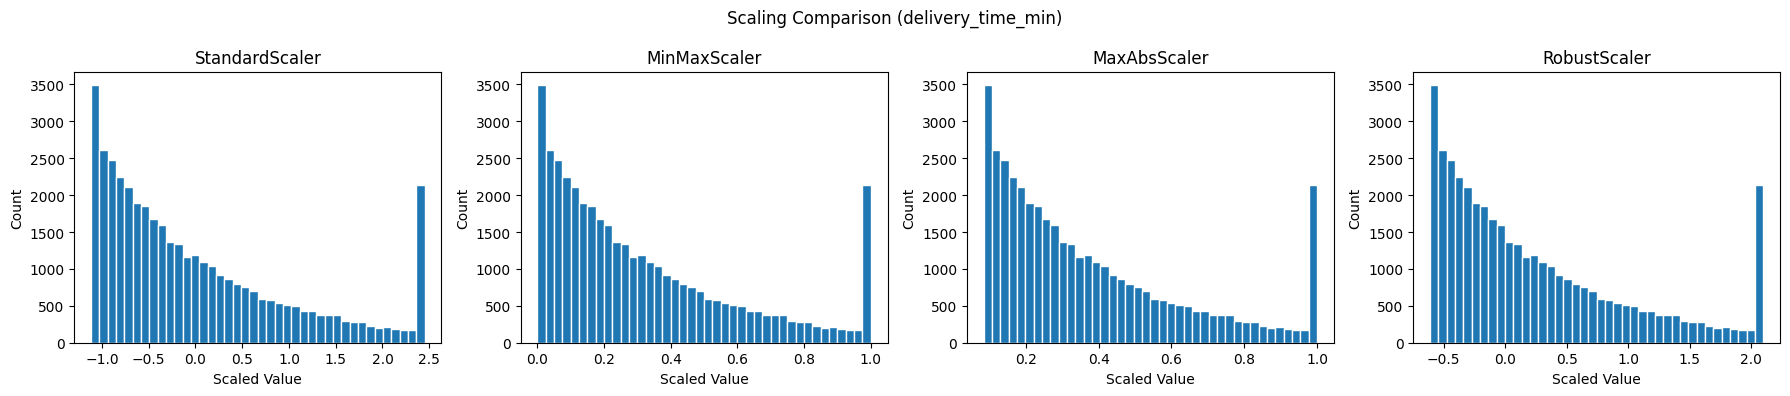

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, data) in zip(axes, scaled_data.items()):

    ax.hist(data["delivery_time_min"], bins=40, edgecolor="white")
    ax.set_title(name)
    ax.set_xlabel("Scaled Value")
    ax.set_ylabel("Count")

plt.suptitle("Scaling Comparison (delivery_time_min)", fontsize=12)
plt.tight_layout()
# plt.savefig("scaling_comparison.png", dpi=100)
# plt.close()

# print("\n[Saved] scaling_comparison.png")


print("RobustScaler is best because it handles outliers effectively,")
print("especially in distance_km and delivery_time_min.")


# TASK 11 │ FINAL COLUMNTRANSFORMER PIPELINE


### --- 11.1 FunctionTransformer ---

In [ ]:
from sklearn.preprocessing import FunctionTransformer

In [ ]:
df_ft = df_bin.copy()

In [ ]:
log_transform = FunctionTransformer(np.log1p, validate=False)
reciprocal_transform = FunctionTransformer(lambda x: 1/(x+1e-5), validate=False)
sqrt_transform = FunctionTransformer(np.sqrt, validate=False)


In [ ]:
df_ft["delivery_time_min"] = pd.to_numeric(df_ft["delivery_time_min"], errors="coerce")
df_ft["distance_km"] = pd.to_numeric(df_ft["distance_km"], errors="coerce")
df_ft["traffic_index"] = pd.to_numeric(df_ft["traffic_index"], errors="coerce")
df_ft["package_weight_kg"] = pd.to_numeric(df_ft["package_weight_kg"], errors="coerce")


df_ft["delivery_time_log"] = log_transform.fit_transform(df_ft[["delivery_time_min"]])
df_ft["distance_log"] = log_transform.fit_transform(df_ft[["distance_km"]])
df_ft["traffic_reciprocal"] = reciprocal_transform.fit_transform(df_ft[["traffic_index"]])
df_ft["weight_sqrt"] = sqrt_transform.fit_transform(df_ft[["package_weight_kg"]])

In [ ]:

print("\nSkewness Comparison (Function Transform):")
for col, new_col in [
    ("delivery_time_min", "delivery_time_log"),
    ("distance_km", "distance_log"),
    ("traffic_index", "traffic_reciprocal"),
    ("package_weight_kg", "weight_sqrt")
]:
    before = df_ft[col].skew()
    after = df_ft[new_col].skew()
    print(f"{col}: Before={before:.2f}, After={after:.2f}, Change={after-before:.2f}")


Skewness Comparison (Function Transform):
delivery_time_min: Before=1.03, After=0.05, Change=-0.98
distance_km: Before=1.61, After=-0.11, Change=-1.72
traffic_index: Before=0.01, After=46.59, Change=46.58
package_weight_kg: Before=1.37, After=0.47, Change=-0.91


### --- 11.2 PowerTransformer ---

In [ ]:
from sklearn.preprocessing import PowerTransformer

In [ ]:
pt_boxcox =  PowerTransformer(method="box-cox")
df_ft["delivery_time_boxcox"] = pt_boxcox.fit_transform(df_ft[["delivery_time_min"]])
print("\n Box-cox Lambda : ",pt_boxcox.lambdas_)



 Box-cox Lambda :  [-0.01943435]


In [ ]:
pt_yeo = PowerTransformer(method="yeo-johnson")

df_ft["traffic_yeo"] = pt_yeo.fit_transform(
    df_ft[["traffic_index"]]
)

In [ ]:
print("\nSkewness Comparison (Power Transform):")
for col, new_col in [
    ("delivery_time_min", "delivery_time_boxcox"),
    ("traffic_index", "traffic_yeo")
]:
    print(f"{col}: Before={df_ft[col].skew():.4f}, After={df_ft[new_col].skew():.4f}")


Skewness Comparison (Power Transform):
delivery_time_min: Before=1.0346, After=0.0045
traffic_index: Before=0.0101, After=-0.1673


### --- 11.3 FINAL COLUMNTRANSFORMER PIPELINE ---

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, PowerTransformer


In [ ]:
df_pipe = df_clean.copy()

In [ ]:
df_pipe.shape

(50000, 19)

In [ ]:
df_pipe.columns

Index(['order_id', 'order_datetime', 'delivery_city', 'delivery_zone',
       'distance_km', 'agent_rating', 'weather_condition', 'traffic_index',
       'vehicle_type', 'package_weight_kg', 'delivery_time_min', 'is_delayed',
       'agent_id', 'agent_name', 'experience_years', 'vehicle_owned',
       'city_assigned', 'joining_date', 'experience_missing'],
      dtype='object')

In [ ]:

# Work from the CLEANED dataframe (before task-6 derived cols) for a clean pipeline demo
df_pipe = df_clean.copy()
df_pipe["order_hour"]    = pd.to_datetime(df_pipe["order_datetime"]).dt.hour
df_pipe["is_weekend"]    = pd.to_datetime(df_pipe["order_datetime"]).dt.dayofweek.isin([5,6]).astype(int)
df_pipe["is_peak_hour"]  = df_pipe["order_hour"].isin([9,10,11,18,19,20,21]).astype(int)
df_pipe["agent_tenure_days"] = (pd.Timestamp("2025-07-01") -
                                 pd.to_datetime(df_pipe["joining_date"])).dt.days
df_pipe["distance_category"] = pd.cut(
    df_pipe["distance_km"], bins=[-np.inf, 5, 15, np.inf], labels=["Short","Medium","Long"])
df_pipe["traffic_severity"]  = pd.cut(
    df_pipe["traffic_index"], bins=[-np.inf,3,6,8,np.inf], labels=["Low","Moderate","High","Severe"])

num_features = ["distance_km", "delivery_time_min", "agent_rating",
                "traffic_index", "package_weight_kg", "agent_tenure_days"]
cat_ohe      = ["delivery_city", "vehicle_type", "weather_condition"]
cat_ord      = ["delivery_zone", "distance_category", "traffic_severity"]

# Keep only columns that exist
num_features = [c for c in num_features if c in df_pipe.columns]
cat_ohe      = [c for c in cat_ohe      if c in df_pipe.columns]
cat_ord      = [c for c in cat_ord      if c in df_pipe.columns]


In [ ]:
df_pipe

,order_id,order_datetime,delivery_city,delivery_zone,distance_km,agent_rating,weather_condition,traffic_index,vehicle_type,package_weight_kg,delivery_time_min,is_delayed,agent_id,agent_name,experience_years,vehicle_owned,city_assigned,joining_date,experience_missing,order_hour,is_weekend,is_peak_hour,agent_tenure_days,distance_category,traffic_severity
0,AMZ-20250425-00000,2025-04-25 19:13:00,Lucknow,D,8.31,3.11,Clear,9.44,Cycle,13.82,23.74,1,AGENT_05773,Agent_5773,7.28,Cycle,Chennai,2019-02-01,0,19,0,1,2342,Medium,Severe
1,AMZ-20250110-00001,2025-01-10 02:58:00,Surat,C,11.62,4.63,Storm,7.22,Scooter,2.66,160.30,0,AGENT_04867,Agent_4867,9.92,Scooter,Ahmedabad,2018-02-05,0,2,0,0,2703,Medium,High
2,AMZ-20250107-00002,2025-01-07 04:36:00,Chandigarh,C,1.71,3.77,Clear,7.30,Bike,1.38,14.25,0,AGENT_00817,Agent_817,3.81,Cycle,Bangalore,2023-01-14,0,4,0,0,899,Short,High
3,AMZ-20250116-00003,2025-01-16 04:05:00,Hyderabad,D,5.73,3.77,Clear,8.91,Van,3.09,132.63,1,AGENT_05587,Agent_5587,0.00,Van,Pune,2023-05-12,1,4,0,0,781,Medium,Severe
4,AMZ-20250312-00004,2025-03-12 19:51:00,Delhi,B,5.07,3.17,Fog,1.50,Van,3.73,83.14,1,AGENT_05724,Agent_5724,3.23,Cycle,Bangalore,2018-12-11,0,19,0,1,2394,Medium,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,AMZ-20250208-49995,2025-02-08 19:37:00,Hyderabad,A,1.05,2.94,Rain,0.72,Cycle,5.54,27.08,1,AGENT_00903,Agent_903,5.23,Van,Bangalore,2022-03-04,0,19,1,1,1215,Short,Low
49996,AMZ-20250205-49996,2025-02-05 16:12:00,Hyderabad,B,2.68,3.95,Clear,4.98,Cycle,3.85,10.78,0,AGENT_03516,Agent_3516,3.93,Van,Chennai,2021-08-20,0,16,0,0,1411,Short,Moderate
49997,AMZ-20250128-49997,2025-01-28 09:38:00,Indore,D,5.61,3.91,Cloudy,6.81,Cycle,9.23,130.67,1,AGENT_05721,Agent_5721,6.08,Cycle,Chandigarh,2023-04-23,0,9,0,1,800,Medium,High
49998,AMZ-20250105-49998,2025-01-05 19:09:00,Hyderabad,A,12.78,4.82,Clear,3.76,Van,3.62,82.71,1,AGENT_00222,Agent_222,3.69,Van,Hyderabad,2024-01-04,0,19,1,1,544,Medium,Moderate


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, OrdinalEncoder,
    StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler,
    PowerTransformer, FunctionTransformer
)
from sklearn.compose import ColumnTransformer


numeric_pipeline = Pipeline([
    ("imputer",   SimpleImputer(strategy="median")),
    ("power",     PowerTransformer(method="yeo-johnson")),
    ("scaler",    RobustScaler()),
])

ohe_pipeline = Pipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
])

ordinal_pipeline = Pipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline,  num_features),
    ("ohe", ohe_pipeline,      cat_ohe),
    ("ord", ordinal_pipeline,  cat_ord),
], remainder="drop")


In [ ]:
X = df_pipe[num_features + cat_ohe + cat_ord]
y = df_pipe["is_delayed"]
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print(f"\nPipeline fitted successfully!")
print(f"  X_train_scaled shape: {X_train_scaled.shape}")
print(f"  X_test_scaled  shape: {X_test_scaled.shape}")
print("  ✓ No data leakage — fit() called on training data only")



Pipeline fitted successfully!
  X_train_scaled shape: (40000, 31)
  X_test_scaled  shape: (10000, 31)
  ✓ No data leakage — fit() called on training data only


In [ ]:
skew_table = []
for col in ["delivery_time_min", "distance_km", "package_weight_kg"]:
    if col not in df_pipe.columns:
        continue
    orig  = df_pipe[col].dropna().skew()
    pt_yj = PowerTransformer("yeo-johnson").fit_transform(df_pipe[[col]]).flatten()
    pt_bc = PowerTransformer("box-cox").fit_transform(
        df_pipe[[col]].clip(lower=1e-6)).flatten()  # box-cox needs positive
    skew_table.append({
        "Column": col,
        "Original Skewness": round(orig, 4),
        "Yeo-Johnson Skewness": round(pd.Series(pt_yj).skew(), 4),
        "Box-Cox Skewness":    round(pd.Series(pt_bc).skew(), 4),
    })
print("\nSkewness Comparison Table:")
print(pd.DataFrame(skew_table).to_string(index=False))



Skewness Comparison Table:
           Column  Original Skewness  Yeo-Johnson Skewness  Box-Cox Skewness
delivery_time_min             2.0067                0.0257            0.0209
      distance_km             2.0471               -0.0076           -0.0290
package_weight_kg             2.0121                0.0364           -0.0380


In [ ]:
df_feat.to_csv("amazon_deliveries_processed.csv", index=False)
print("\n[Saved] amazon_deliveries_processed.csv")



[Saved] amazon_deliveries_processed.csv
